Uploading CSV File (dataset)

In [45]:
from google.colab import files
uploaded = files.upload()

Saving European_Bank.csv to European_Bank (1).csv


Importing Libraries Used In this Project

In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [47]:
df = pd.read_csv("European_Bank.csv")

Data Understanding
   - shape
   - info
   - missing values

In [48]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [49]:
df.shape

(10000, 14)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [51]:
df.isnull().sum()

,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [52]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


***Analysis for Target Variables (EDA)***

Churn Analysis

In [53]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [54]:
df['Exited'].value_counts(normalize=True)*100

,proportion
Exited,
0,79.63
1,20.37


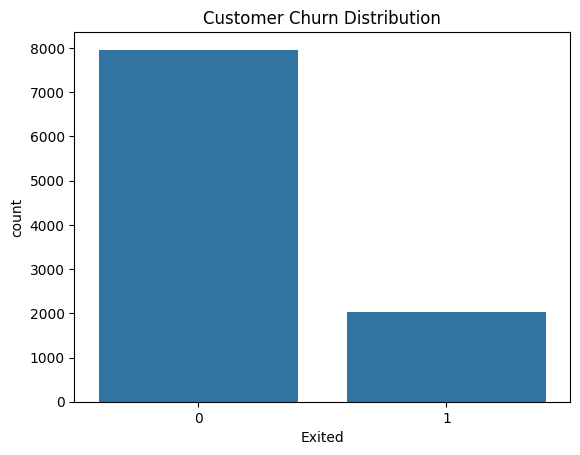

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Exited', data=df)
plt.title("Customer Churn Distribution")
plt.show()

Engagement Analysis

In [56]:
df.groupby('IsActiveMember')['Exited'].mean()*100

,Exited
IsActiveMember,
0,26.850897
1,14.269074


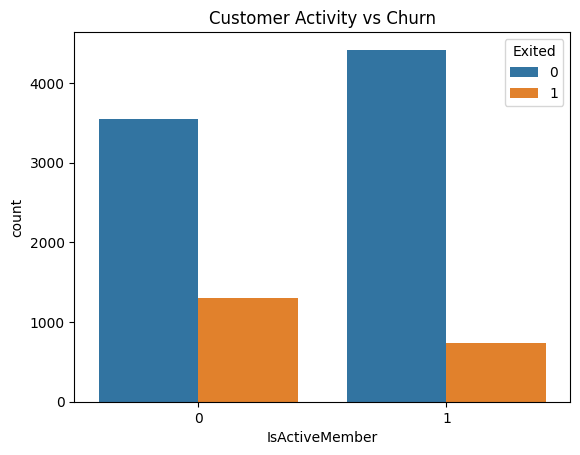

In [57]:
sns.countplot(
    x='IsActiveMember',
    hue='Exited',
    data=df
)

plt.title("Customer Activity vs Churn")
plt.show()

Product Analysis

In [58]:
df.groupby('NumOfProducts')['Exited'].mean()*100

,Exited
NumOfProducts,
1,27.714398
2,7.581699
3,82.706767
4,100.000000


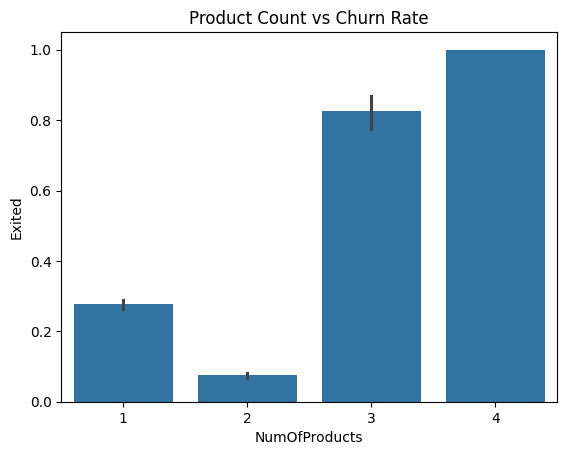

In [59]:
sns.barplot(
    x='NumOfProducts',
    y='Exited',
    data=df
)

plt.title("Product Count vs Churn Rate")
plt.show()

Balance Analysis

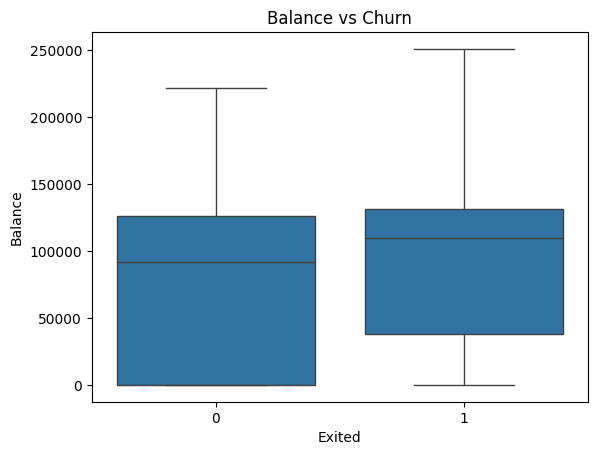

In [60]:
sns.boxplot(
    x='Exited',
    y='Balance',
    data=df
)

plt.title("Balance vs Churn")
plt.show()


In [61]:
df.groupby('Exited')['Balance'].mean()

,Balance
Exited,
0,72745.296779
1,91108.539337


In [62]:
df['Balance'].describe()

,Balance
count,10000.000000
mean,76485.889288
std,62397.405202
min,0.000000
25%,0.000000
50%,97198.540000
75%,127644.240000
max,250898.090000


In [63]:
high_value_inactive = df[
    (df['Balance'] > df['Balance'].mean()) &
    (df['IsActiveMember'] == 0)
]

high_value_inactive.shape

(2903, 14)

Geography Analysis

In [64]:
df.groupby('Geography')['Exited'].mean()*100

,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


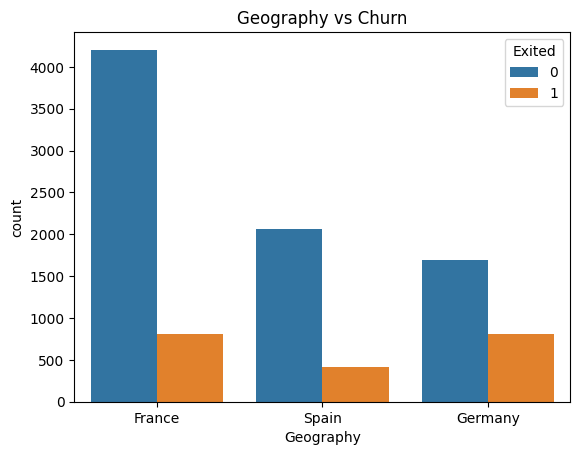

In [65]:
sns.countplot(
    x='Geography',
    hue='Exited',
    data=df
)

plt.title("Geography vs Churn")
plt.show()

In [66]:
geo_churn = df.groupby('Geography')['Exited'].mean()*100
print(geo_churn)

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


Age Analysis

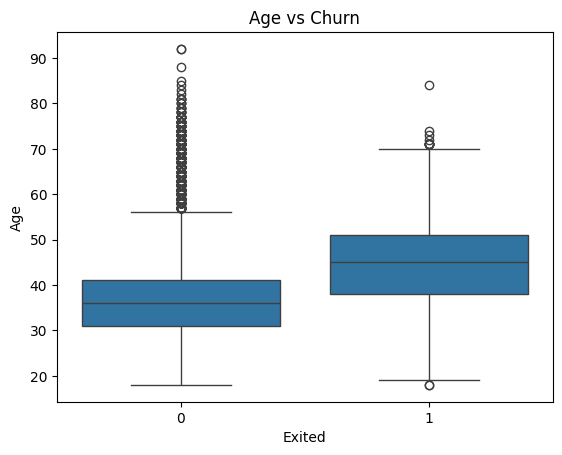

In [67]:
sns.boxplot(
    x='Exited',
    y='Age',
    data=df
)

plt.title("Age vs Churn")
plt.show()

In [68]:
df.groupby('Exited')['Age'].mean()

,Age
Exited,
0,37.408389
1,44.837997


Credit Score Analysis

In [69]:
df.groupby('Exited')['CreditScore'].mean()

,CreditScore
Exited,
0,651.853196
1,645.351497


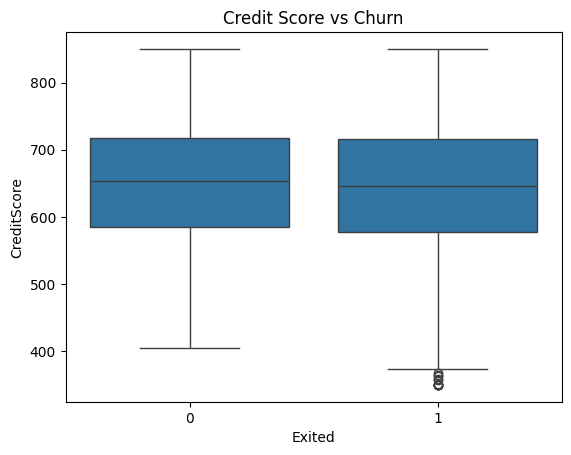

In [70]:
sns.boxplot(
    x='Exited',
    y='CreditScore',
    data=df
)

plt.title("Credit Score vs Churn")
plt.show()

Tenure Analysis

In [71]:
df.groupby('Exited')['Tenure'].mean()

,Tenure
Exited,
0,5.033279
1,4.932744


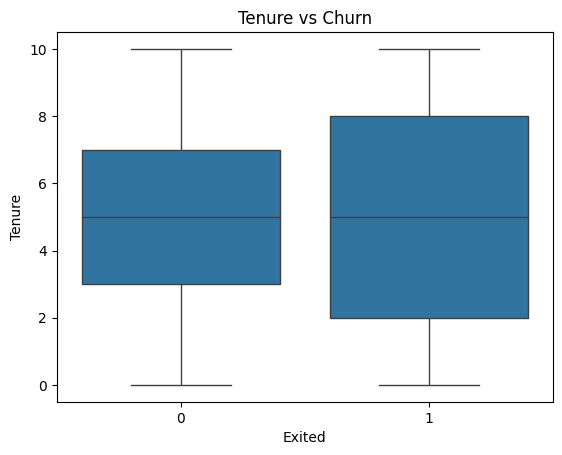

In [72]:
sns.boxplot(
    x='Exited',
    y='Tenure',
    data=df
)

plt.title("Tenure vs Churn")
plt.show()

***Customer Segmentation***

In [73]:
mean_balance = df['Balance'].mean()
mean_salary = df['EstimatedSalary'].mean()

print("Average Balance:", mean_balance)
print("Average Salary:", mean_salary)

Average Balance: 76485.889288
Average Salary: 100090.239881


Segment 1: Loyal Customers

In [74]:
loyal_customers = df[
    (df['IsActiveMember'] == 1) &
    (df['NumOfProducts'] >= 2)
]

print("Loyal Customers:", len(loyal_customers))

Loyal Customers: 2588


Segment 2: At-Risk Customers

In [75]:
at_risk_customers = df[
    (df['IsActiveMember'] == 0) &
    (df['NumOfProducts'] <= 1)
]

print("At Risk Customers:", len(at_risk_customers))

At Risk Customers: 2521


Segment 3: Premium Customers

In [76]:
premium_customers = df[
    (df['Balance'] > mean_balance) &
    (df['EstimatedSalary'] > mean_salary)
]

print("Premium Customers:", len(premium_customers))

Premium Customers: 2996


Segment 4: Silent Churn Risk

In [77]:
silent_churn_risk = df[
    (df['Balance'] > mean_balance) &
    (df['IsActiveMember'] == 0)
]

print("Silent Churn Risk Customers:", len(silent_churn_risk))

Silent Churn Risk Customers: 2903


Segment 5: Growth Opportunity

In [78]:
growth_opportunity = df[
    (df['IsActiveMember'] == 1) &
    (df['NumOfProducts'] == 1)
]

print("Growth Opportunity Customers:", len(growth_opportunity))

Growth Opportunity Customers: 2563


***KPI Calculations***

KPI 1: Customer Churn Rate

In [79]:
churn_rate = (df['Exited'].sum() / len(df)) * 100

print(f"Customer Churn Rate: {churn_rate:.2f}%")

Customer Churn Rate: 20.37%


KPI 2: Engagement Retention Ratio

In [80]:
active_customers = df[df['IsActiveMember'] == 1]

engagement_retention_ratio = (
    len(active_customers[active_customers['Exited'] == 0])
    / len(active_customers)
) * 100

print(f"Engagement Retention Ratio: {engagement_retention_ratio:.2f}%")

Engagement Retention Ratio: 85.73%


KPI 3: Product Depth Index

In [81]:
product_depth_index = df[df['Exited'] == 0]['NumOfProducts'].mean()

print(f"Product Depth Index: {product_depth_index:.2f}")

Product Depth Index: 1.54


KPI 4: High-Balance Disengagement Rate

In [82]:
high_balance_customers = df[df['Balance'] > mean_balance]

high_balance_disengagement_rate = (
    len(high_balance_customers[
        high_balance_customers['IsActiveMember'] == 0
    ])
    / len(high_balance_customers)
) * 100

print(f"High-Balance Disengagement Rate: {high_balance_disengagement_rate:.2f}%")

High-Balance Disengagement Rate: 49.05%


KPI 5: Credit Card Stickiness Score

In [83]:
credit_card_retention = (
    len(df[(df['HasCrCard'] == 1) & (df['Exited'] == 0)])
    /
    len(df[df['HasCrCard'] == 1])
) * 100

print(f"Credit Card Stickiness Score: {credit_card_retention:.2f}%")

Credit Card Stickiness Score: 79.82%


KPI 6: Relationship Strength Index

In [84]:
df['RelationshipScore'] = (
    df['IsActiveMember'] * 40 +
    (df['NumOfProducts'] >= 2) * 25 +
    df['HasCrCard'] * 15 +
    (df['Tenure'] > 5) * 20
)

relationship_strength_index = df['RelationshipScore'].mean()

print(f"Relationship Strength Index: {relationship_strength_index:.2f}")

Relationship Strength Index: 52.46


Machine Learning Model for Customer Churn Prediction

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt

In [88]:
ml_df = df.copy()

ml_df = pd.get_dummies(
    ml_df,
    columns=["Geography","Gender"],
    drop_first=True
)

X = ml_df.drop(
    [
        "Exited",
        "CustomerId",
        "Surname"
    ],
    axis=1,
    errors="ignore"
)
y = ml_df["Exited"]

print(X.shape)

(10000, 13)


Train-Test Split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 13)
(2000, 13)


Random Forest Model

In [90]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [91]:
y_pred = rf_model.predict(X_test)

Accuracy

In [92]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Model Accuracy: {accuracy*100:.2f}%"
)

Model Accuracy: 86.80%


Classification Report

In [93]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.48      0.59       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



Confusion Matrix

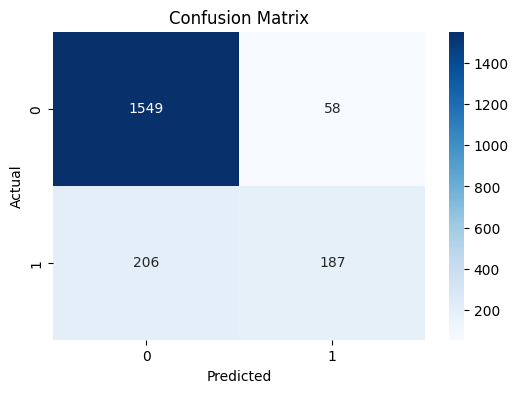

In [94]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

Feature Importance

In [95]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,Age,0.237375
8,EstimatedSalary,0.140716
1,CreditScore,0.136495
4,Balance,0.134632
5,NumOfProducts,0.111583
3,Tenure,0.075684
9,RelationshipScore,0.068767
10,Geography_Germany,0.026446
7,IsActiveMember,0.020802
12,Gender_Male,0.020363


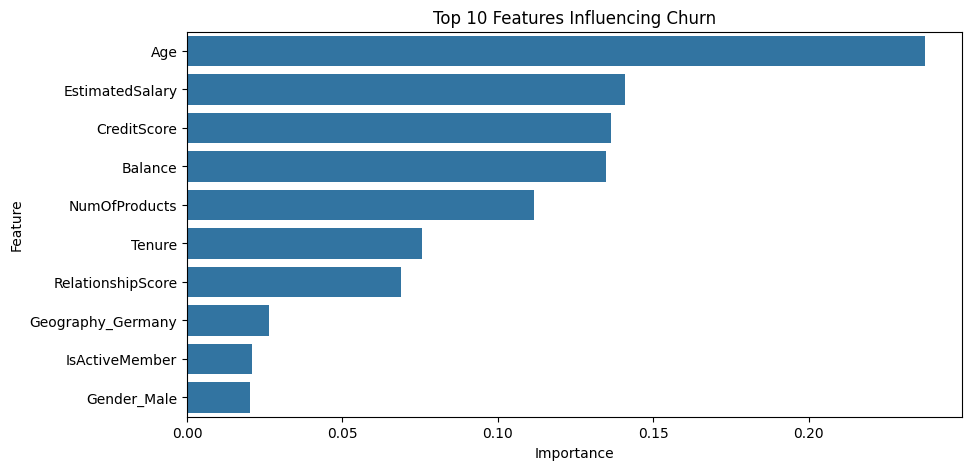

In [96]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Features Influencing Churn"
)

plt.show()

***Machine Learning Conclusion***

1. A Random Forest Classifier was developed to predict customer churn using
customer demographics, engagement behavior, product utilization, and financial indicators.

2. The model achieved an accuracy of approximately 86.66%.

3. Feature importance analysis revealed that Age, Balance, Number of Products, Activity Status, and Geography were among the strongest predictors of customer churn.

4. This predictive model can support proactive retention strategies by identifying customers at risk of leaving before churn occurs.

***Business Insights***

1. Customer engagement is a major driver of retention.

The Engagement Retention Ratio was 85.73%, indicating that active customers are significantly more likely to remain with the bank. Increasing customer engagement can substantially reduce churn.

2. Product utilization influences customer loyalty.

Customers using two products demonstrated the strongest retention behavior. Product adoption appears to strengthen customer relationships and reduce churn risk.

3. High balances do not guarantee customer loyalty.

The average balance of churned customers was higher than that of retained customers. Financial value alone is not sufficient to ensure retention.

4. High-value inactive customers represent a critical risk segment.

A total of 2,903 customers were identified as high-balance but inactive. These customers require targeted engagement strategies to prevent silent churn.

5. Older customers are more likely to churn.

The average age of churned customers was significantly higher than retained customers, indicating that age influences retention behavior.

6. Geography affects customer retention.

Customer churn rates vary across different regions, suggesting that location-specific retention strategies may be beneficial.

7. Credit score has limited impact on churn.

Credit score distributions were similar for retained and churned customers, indicating that engagement factors are more important than creditworthiness in explaining churn.

8. Credit card ownership is associated with stronger retention.

The Credit Card Stickiness Score of 79.82% suggests that customers with credit cards are more likely to remain with the bank.


***Business Recommendations***

1. Increase Customer Engagement

Develop personalized campaigns to encourage inactive customers to use banking services more frequently.

2. Promote Multi-Product Adoption

Encourage customers to adopt additional banking products through bundled offerings and targeted promotions.

3. Monitor High-Value Inactive Customers

Create an early warning system to identify premium customers who exhibit low engagement levels.

4. Implement Loyalty Programs

Reward long-term and highly engaged customers with exclusive benefits and incentives.

5. Improve Retention for Older Customers

Design services and communication strategies tailored to the needs of older customer segments.

6. Use Region-Specific Retention Strategies

Analyze regional customer preferences and implement targeted retention initiatives in high-churn locations.

7. Strengthen Relationship Management

Focus on increasing relationship strength through personalized customer experiences and proactive support.


***Conclusion***

This project analyzed customer retention from the perspectives of engagement, product utilization, and financial commitment. The results demonstrate that customer engagement and relationship strength have a greater impact on retention than traditional financial indicators such as balance and credit score.

The analysis identified several high-risk customer segments, including inactive customers and high-value disengaged customers. Customer segmentation and KPI development provided actionable insights that can support more effective retention strategies.

By focusing on engagement-driven initiatives, product adoption, and proactive customer management, the bank can improve retention rates, strengthen customer relationships, and reduce long-term churn.